# IPL Model Comparison

In [1]:
!pip install scikit-learn imbalanced-learn xgboost seaborn
import time, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from collections import Counter
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
TEAM_NAMES = ['None','CSK','DC','GT','KKR','LSG','MI','PBKS','RR','RCB','SRH']
print('Libraries loaded!')

Libraries loaded!


## Load data and apply imbalance handling

In [2]:
X = np.load('X.npy')
y = np.load('y.npy')
print('Loaded X:', X.shape, '  y:', y.shape)

dist = Counter(y)
player_counts = [dist.get(t, 0) for t in range(1, 11) if dist.get(t, 0) > 0]
median_player = int(np.median(player_counts))

# Undersample class 0 and over-represented teams
under_targets = {0: median_player * 5}
for t in [3, 4]:
    if dist.get(t, 0) > median_player * 3:
        under_targets[t] = median_player * 3
X_u, y_u = RandomUnderSampler(sampling_strategy=under_targets, random_state=42).fit_resample(X, y)

# SMOTE for rare teams
dist2 = Counter(y_u)
target_n = max(dist2.get(t, 0) for t in range(1, 11))
smote_target = {t: target_n for t in range(1,11) if 0 < dist2.get(t,0) < target_n}
k = max(1, min(5, min((v for v in dist2.values() if v > 0), default=2) - 1))
X_s, y_s = SMOTE(sampling_strategy=smote_target, k_neighbors=k, random_state=42).fit_resample(X_u, y_u)

X_train, X_test, y_train, y_test = train_test_split(X_s, y_s, test_size=0.2, stratify=y_s, random_state=42)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Loaded X: (251776, 560)   y: (251776,)
Train: (46008, 560)  Test: (11502, 560)


## Define models

In [3]:
MODELS = {
    'XGBoost': Pipeline([('s', StandardScaler()), ('c', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='mlogloss', n_jobs=-1, random_state=42))])
}
print('Defined', len(MODELS), 'models')

Defined 1 models


## Train and evaluate all models

In [4]:
results, trained_models = [], {}

for name, model in MODELS.items():
    print(f'Training {name}...', end=' ', flush=True)
    t0 = time.time(); 
    model.fit(X_train, y_train); train_time = time.time() - t0
    train_acc = model.score(X_train, y_train)
    test_acc  = model.score(X_test, y_test)
    y_pred    = model.predict(X_test)
    report    = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    t0 = time.time(); _ = model.predict(X_test[:100]); infer_ms = (time.time()-t0)/100*1000
    cv = cross_val_score(model, X_s, y_s, cv=3, n_jobs=-1)
    row = {'Model': name, 'Train Acc': round(train_acc,4), 'Test Acc': round(test_acc,4),
           'CV Mean': round(cv.mean(),4), 'CV Std': round(cv.std(),4),
           'Train Time (s)': round(train_time,2), 'Infer Time (ms)': round(infer_ms,3),
           'Overfit Gap': round(train_acc-test_acc,4)}
    for i, t in enumerate(TEAM_NAMES):
        row[f'F1_{t}'] = round(report.get(str(i), {}).get('f1-score', 0.0), 3)
    results.append(row) 
    trained_models[name] = model
    #model.save(f'{name.replace(" ", "_").lower()}_model.pkl')
    joblib.dump(model, f'{name.replace(" ", "_").lower()}_model.pkl')
    print(f'Test={test_acc:.3f}  Time={train_time:.1f}s')

df = pd.DataFrame(results).sort_values('Test Acc', ascending=False).reset_index(drop=True)
df.to_csv('model_comparison_results_5.csv', index=False)
print('\nSaved model_comparison_results.csv')
df[['Model','Train Acc','Test Acc','CV Mean','CV Std','Train Time (s)','Overfit Gap']]

Training XGBoost... Test=0.856  Time=344.3s

Saved model_comparison_results.csv


,Model,Train Acc,Test Acc,CV Mean,CV Std,Train Time (s),Overfit Gap
0,XGBoost,0.9982,0.8564,0.8355,0.0276,344.32,0.1418


## Save best model

In [5]:
best_name  = df.iloc[0]['Model']
best_model = trained_models[best_name]
joblib.dump(best_model, 'best_model_group45.pkl')
print(f'Best model: {best_name}')
print(f'Test Acc  : {df.iloc[0]["Test Acc"]}')
print(f'CV Mean   : {df.iloc[0]["CV Mean"]} ± {df.iloc[0]["CV Std"]}')
print('Saved model_group45.pkl')

Best model: XGBoost
Test Acc  : 0.8564
CV Mean   : 0.8355 ± 0.0276
Saved model_group45.pkl


## Confusion matrix for best model

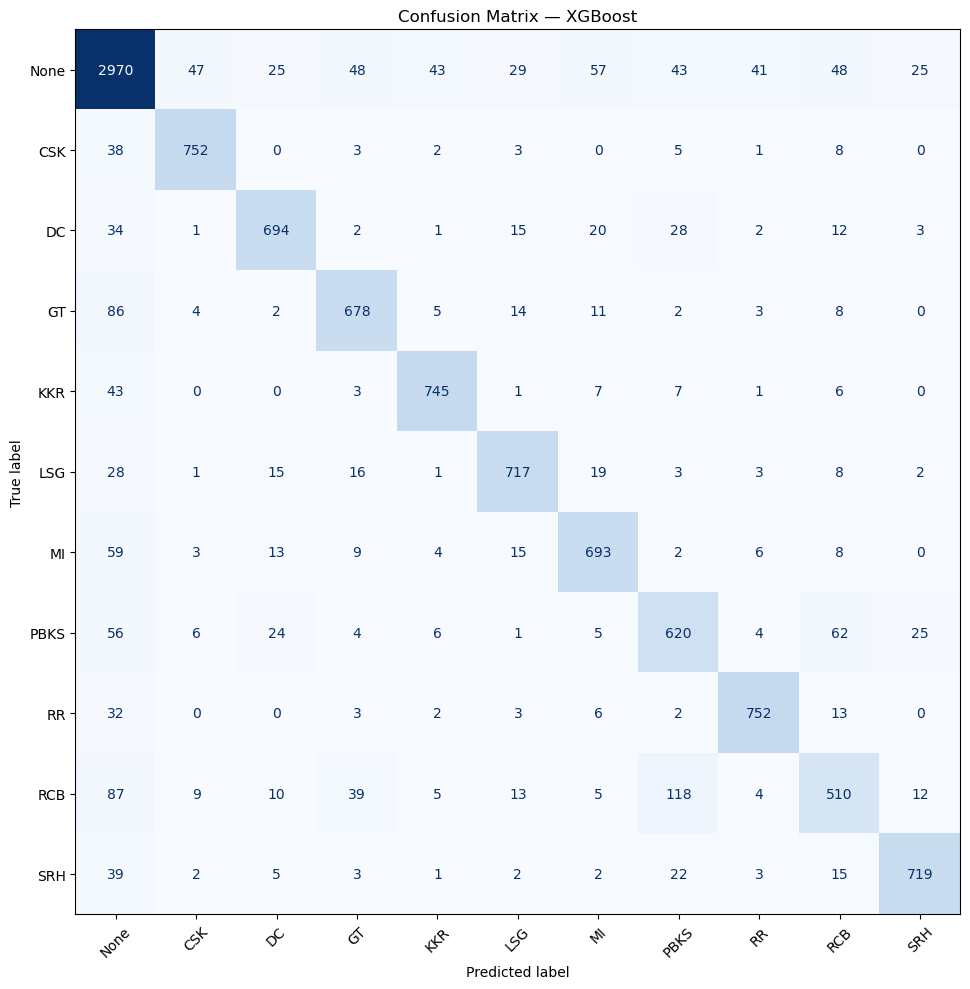

In [6]:
y_pred = trained_models[best_name].predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm, display_labels=TEAM_NAMES).plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}'); plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()